https://www.kaggle.com/code/mohammedmokhtar77/customer-shopping-trends-dataset
https://www.xiaohongshu.com/explore/691195420000000005031ea2?app_platform=ios&app_version=8.66&share_from_user_hidden=true&xsec_source=app_share&type=normal&xsec_token=CBpXz-48LlSYHOWN1fb6xlhxiD9xvCMYD67bh4kjRi6Sc=&author_share=1&xhsshare=CopyLink&shareRedId=ODo2MEY6SUo2NzUyOTgwNjg8OTg6RjhP&apptime=1762912162&share_id=68a222cf0d7c488d8c686433f977ebc7

用户消费行为与偏好分析
numpy pandas matplotlib
一、分析目的
通过对客户购物行为数据进行多维度分析,旨在深入理解消费者画像特征、产品偏好、购买习惯及支付方式等关键因素,挖掘不同用户群体的行为差异与潜在规律。最终为精准营销策略制定、产品品类优化、库存管理以及用户忠诚度提升提供数据驱动的决策支持,进一步提升客户体验与商业效益。


二、数据概览
数据集:
客户购物偏好数据集_readme.md
shopping_trends.csv

In [18]:
#导入库
import numpy             as np    # lumPy库,用于科学计算
import pandas            as pd    # 导入Pandas库,用于数据处理和分析
import matplotlib.pyplot as plt   #导入Matplotlib的pyplot模块,用于绘图
import seaborn           as sns   # Seaborn库,基于Matplotlib的统计可视化库
import datetime                   # datetime库,用于处理日期和时间:
import warnings                   #  warmings库,用于控制警告信息
warnings.filterwarnings('ignore') # 忽略所有警告信息,避免输出不必要的警告
%matplotlib inline
#JupyterLab魔法命令,使图表直接显示在笔记本中


# *设置Matplotlib的pyplot模块默认字体为需体(Sintet),以支持中文显示
plt.rcParams['font.sans-serif'] = 'SimHei'
#数据读取
#data= pd.read_excel('D:\文档\工作、简历、作品合集、数据集\shopping trends.xlsx')
data= pd.read_csv("C:/Users/zhen-/.cache/kagglehub/datasets/iamsouravbanerjee/customer-shopping-trends-dataset/versions/2/shopping_trends_updated.csv")
data

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [19]:
data.info() # check the data type of each column 尤其是有没有缺失值

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [20]:
data['Customer ID'] = data['Customer ID'].astype(object)
print(data['Customer ID'].dtype)
print(data['Customer ID'].head())


object
0    1
1    2
2    3
3    4
4    5
Name: Customer ID, dtype: object


检测有无重复值

In [21]:
print(data.duplicated().sum())


0


只保留第一个重复值，其余的重复值全部删除

In [22]:
data.drop_duplicates(keep = 'first', inplace=True)

In [23]:
data.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


有一些异常需要依据常识，比如消费金额不能为负数等等，不能为零，不能为空

四、分析维度
分析维度围绕以下六大核心方向展开:
一是消费者画像分析,包括年龄区间与购买力群体特征、性别差异与消费水平对比,以及高消费州/地区分布与地域偏好;
二是产品与品类分析,涵盖热门商品类别、品类平均消费金额、颜色偏好以及季节性销售波动;
三是购买行为分析,聚焦客单价分布、折扣与促销码的使用行为及其对消费金额的影响,并比较订阅用户与非订阅用户的消费差异;
四是支付与配送偏好分析,包括常用支付方式、配送类型偏好,以及配送方式与消费金额、购买频次之间的关联;
五是复购与忠诚度分析,涉及历史购买次数分布、购买频率划分,并挖掘高复购用户的人口属性与行为特征;
六是用户反馈分析,围绕评分分布展开,探索高/低分订单的商品与品类共性,以及评分与消费金额、折扣使用等因素的相关性。

In [24]:
print("年龄描述性统计:")
print(data['Age'].describe())


年龄描述性统计:
count    3900.000000
mean       44.068462
std        15.207589
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Age, dtype: float64


In [25]:
bins = [17, 25, 35, 45, 55, 65,70]

labels = ['18-25岁','26-35岁', '36-45岁', '46-55岁', '56-65岁', '65岁以上'] 
data['Age Group'] = pd.cut( data['Age'], bins = bins, labels =labels, right=True)

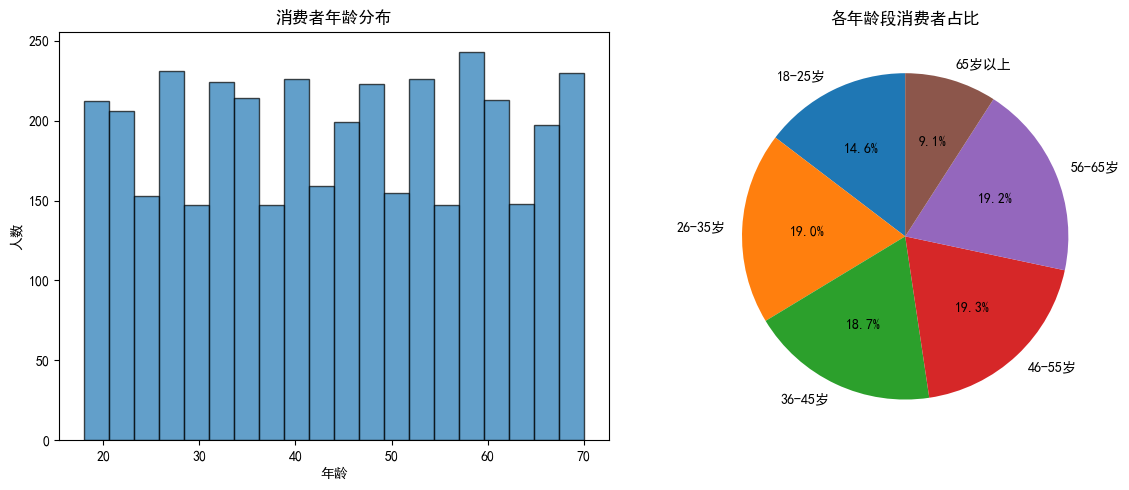

In [27]:
#绘制年齡分布图
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(data['Age'], bins=20, edgecolor='black', alpha=0.7)

plt.title('消费者年龄分布')
plt.xlabel('年龄')
plt.ylabel('人数')

plt.subplot(1, 2, 2)
age_group_counts = data['Age Group'].value_counts().sort_index()


plt.pie( age_group_counts, labels = age_group_counts.index, autopct='%1.1f%%',startangle=90)
plt.title('各年龄段消费者占比')
plt.tight_layout()
plt.show()
